### Load Dependencies

In [1]:
import torch
import torch.optim as optim
import torch.distributed as dist
from torch.utils.data import DataLoader
import numpy as np
from torch.utils.data import SubsetRandomSampler

from src.dataset import DSMShadeDataset
from src.model import ShadyModel

### Define Parameters

In [2]:
# Directory containing training data
TEST_TILE_PATH = "/Users/luc/Geomatics/Thesis/Data/input/271110_Ams/test_tiles/dsms/combined/"
TEST_SHADE_PATH = "/Users/luc/Geomatics/Thesis/Data/output/tree_shade/"
CSV_PATH = "/Users/luc/Geomatics/Thesis/ShadyShenanigans/resources/dataset.csv"

# Set Acceleration Device
device = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available()
else "cpu")
print(device)
# Hyperparameters
tile_size = 512

input_size = 0  # What is the resolution of the images?
epochs = 10
LAMBDA = 100
optimizer_learning_rate = 0.0002
# Todo experiment with not messing with this value? (defined in DCGAN paper apparently)
optimizer_momentum = 0.5
# # Todo, how to find how many GPUS are available?
ngpu = 1
if device == torch.device("cpu"):
    ngpu = 0

mps


In [3]:
# Instantiate the custom dataset
dataset = DSMShadeDataset(CSV_PATH, TEST_TILE_PATH, TEST_SHADE_PATH, tile_size=tile_size)

# Define train and test dataloaders
batch_size = 1
validation_split = .2
shuffle_dataset = True
random_seed = 42

# Creating data indices for training and validation splits:
dataset_size = len(dataset)
indices = list(range(dataset_size))
split = int(np.floor(validation_split * dataset_size))
if shuffle_dataset:
    np.random.seed(random_seed)
    np.random.shuffle(indices)
train_indices, val_indices = indices[split:], indices[:split]

# Create data samplers and loaders:
train_sampler = SubsetRandomSampler(train_indices)
valid_sampler = SubsetRandomSampler(val_indices)

train_loader = DataLoader(dataset, batch_size=batch_size, sampler=train_sampler)
validation_loader = DataLoader(dataset, batch_size=batch_size, sampler=valid_sampler)

print(len(train_loader), len(validation_loader))

19757 4939


In [4]:
model = ShadyModel(ngpu, device, tile_size)
model.setup_models()
# disc_loss = nn.BCELoss  # bce loss
# disc_optimizer = optim.Adam(model.parameters(), lr=optimizer_learning_rate, betas=(optimizer_momentum, 0.999))
gen_optimizer = optim.Adam(params=model.generator.parameters(), lr=optimizer_learning_rate, betas=(optimizer_momentum, 0.999))

### Training Loop

In [5]:
# Todo include epochs
# for epoch in range(epochs):
final_result = None
final_target = None
best_loss = np.inf
for i, data in enumerate(train_loader, 0):
    source = data["source"]
    target = data["target"]
    source, target = source.to(device), target.to(device)
    ### FORWARD PASS ###
    y_hat = model.generator(source)

    ### LOSS CALCULATION ###
    loss = model.discriminator(y_hat, target)

    ### BACKPROPAGATION ###
    gen_optimizer.zero_grad()
    loss.backward()
    gen_optimizer.step()

    # Todo: How does discriminator optimization look, same time?

    # TODO: TESTING IF PIPELINE WORKS AT ALL
    if i % 100 == 0:
        print(f"Epoch {i} | Loss {loss.item():.4f}")
        final_result = y_hat
        final_target = target

    # Todo: don't
    if i == 2000:
        break

Epoch 0 | Loss 0.2762
Epoch 100 | Loss 0.4735
Epoch 200 | Loss 0.4899
Epoch 300 | Loss 0.4794
Epoch 400 | Loss 0.4909
Epoch 500 | Loss 0.4840
Epoch 600 | Loss 0.4857
Epoch 700 | Loss 0.4851
Epoch 800 | Loss 0.4829
Epoch 900 | Loss 0.4867
Epoch 1000 | Loss 0.4882
Epoch 1100 | Loss 0.4881
Epoch 1200 | Loss 0.4808
Epoch 1300 | Loss 0.4734
Epoch 1400 | Loss 0.4675
Epoch 1500 | Loss 0.4927
Epoch 1600 | Loss 0.4757
Epoch 1700 | Loss 0.4779
Epoch 1800 | Loss 0.4784
Epoch 1900 | Loss 0.4749
Epoch 2000 | Loss 0.4883


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

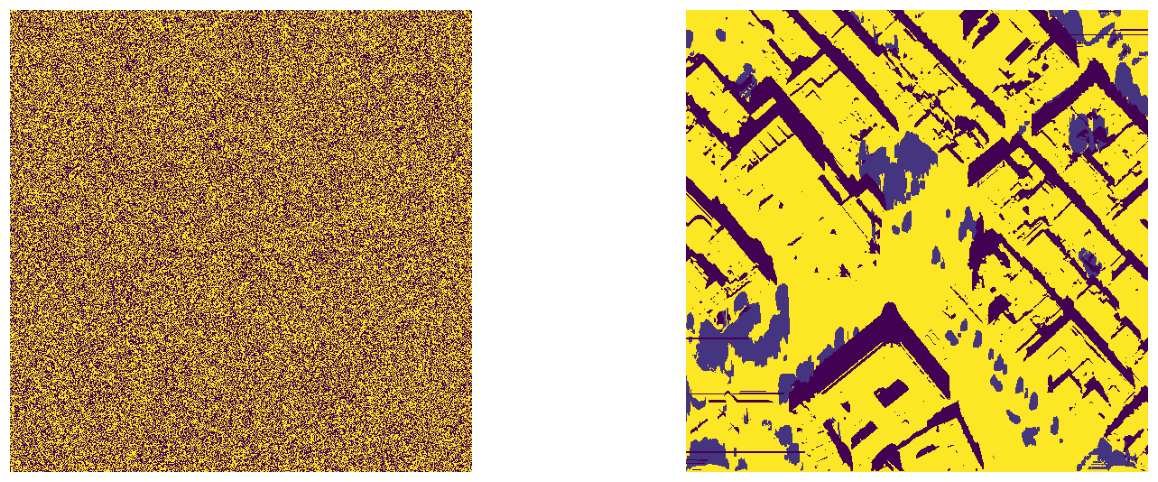

In [6]:
from matplotlib import pyplot as plt
final_result_cpu = final_result.cpu().detach()
final_target_cpu = final_target.cpu().detach()

plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
result = final_result_cpu[0]
plt.imshow(result.squeeze().numpy())
plt.axis('off')

plt.subplot(1, 2, 2)
result = final_target_cpu[0]
plt.imshow(result.squeeze().numpy())
plt.axis('off')